# 1. Set Up Environment

In [ ]:
# Install dependency
!pip install -q spectral

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 7.4 MB/s eta 0:00:00


In [ ]:
import spectral
print("Spectral version:", spectral.__version__)

Spectral version: 0.24


## 1.1 Dependencies

In [ ]:
import subprocess, sys
print("[1/5] Checking CUDA...")
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout[:300] if result.returncode == 0 else "  No GPU detected! Enable GPU runtime.")

print("\n[2/5] Installing core packages...")
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "einops", "scikit-learn", "scipy", "matplotlib",
                "seaborn", "tqdm", "spectral"], check=False)

[1/5] Checking CUDA...
Wed Apr 22 05:27:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------

[2/5] Installing core packages...


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'einops', 'scikit-learn', 'scipy', 'matplotlib', 'seaborn', 'tqdm', 'spectral'], returncode=0)

In [ ]:
!pip uninstall -y mamba-ssm causal-conv1d
!pip install causal-conv1d>=1.4.0 --no-build-isolation
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.7/121.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.1-cp312-cp312-linux_x86_64.whl size=533592144 sha256=d66a3c4c94a693e02d341cace7a6af0b72177b6afa655a25e3a6505130a68cbf
  Stored in directory: /root/.cache/pip/wheels/28/83/54/d45107838fec575b93f5d723f56351cee19a1b13bcd4ec9f3f
Successfully built mamba-ssm


In [ ]:
!pip list | grep -iE "mamba|causal"

causal_conv1d                            1.6.1
mamba-ssm                                2.3.1


## 1.2 Setup Direktori Hasil

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Path hasil di Google Drive
DRIVE_BASE       = '/content/drive/MyDrive/Master/Research/HAD-Experiment/Result-2'
DRIVE_MODEL_DIR  = os.path.join(DRIVE_BASE, 'models')
DRIVE_RESULT_DIR = os.path.join(DRIVE_BASE, 'results')
DRIVE_CKPT_DIR   = os.path.join(DRIVE_BASE, 'checkpoints')   # untuk resume training

for d in [DRIVE_BASE, DRIVE_MODEL_DIR, DRIVE_RESULT_DIR, DRIVE_CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

# Local artifacts (sementara di Colab, lalu di-sync ke Drive)
os.makedirs('artifacts/models',      exist_ok=True)
os.makedirs('artifacts/results',     exist_ok=True)
os.makedirs('artifacts/checkpoints', exist_ok=True)

print(f"Drive mounted.")
print(f"  Result dir  : {DRIVE_RESULT_DIR}")
print(f"  Model dir   : {DRIVE_MODEL_DIR}")
print(f"  Checkpoint  : {DRIVE_CKPT_DIR}")

Drive mounted.
  Result dir  : /content/drive/MyDrive/Master/Research/HAD-Experiment/Result-2/results
  Model dir   : /content/drive/MyDrive/Master/Research/HAD-Experiment/Result-2/models
  Checkpoint  : /content/drive/MyDrive/Master/Research/HAD-Experiment/Result-2/checkpoints


## 1.3 Configuration

In [ ]:
import os, random, time, warnings, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import shutil
from torch.utils.data import Dataset, DataLoader
from datetime import datetime
from scipy.ndimage import median_filter
from scipy.stats import rankdata
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve, auc)
from tqdm import tqdm
from einops import rearrange
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import spectral

warnings.filterwarnings('ignore')

# ─── SEED ───────────────────────────────────────────────────────────────────
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
else:
    print("  WARNING: CPU mode — training akan lambat. Aktifkan GPU runtime.")

# ─── HYPERPARAMETERS ────────────────────────────────────────────────────────


# Model (sesuai main.py GitHub)
BLOCK_SIZE   = 16
STRIDE_PATCH = 8
DIM          = 64
DEPTH        = 1
SPEC_NUM     = 12
SPEC_RATE    = 0.5
SPA_TOKEN    = 16
MODE         = 'full'        # 'spatial' | 'spectral' | 'full'

# Training (sesuai main.py GitHub)
BATCH_SIZE   = 32
EPOCHS       = 500           # Upper limit — actual stop via Universal Early Stopping (patience=50)
LR           = 5e-4
WEIGHT_DECAY = 1e-4

# Spatial guillotine split
TRAIN_Y_START, TRAIN_Y_END = 50, 200
VAL_Y_START,   VAL_Y_END   = 300, 350

print(f"\nKonfigurasi:")
print(f"  Mode       : {MODE}")
print(f"  Block size : {BLOCK_SIZE}x{BLOCK_SIZE}, stride={STRIDE_PATCH}")
print(f"  Epochs     : {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}")

Device: cuda
  GPU: NVIDIA A100-SXM4-40GB

Konfigurasi:
  Mode       : full
  Block size : 16x16, stride=8
  Epochs     : 500 | Batch: 32 | LR: 0.0005


# 2. Get Dataset

In [ ]:
# 2. Setup Kaggle API
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/API/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# 3. Download jika belum ada
DATA_DIR = "/content/data"
DATASET_NAME = "inyunita/anomalyonfood"

if not os.path.exists(DATA_DIR):
    print("Download dataset...")
    !kaggle datasets download -d $DATASET_NAME
    !unzip -q *.zip -d /content/data
    print("Dataset Downloaded")
else:
    print("Dataset Ready")

Download dataset...
Dataset URL: https://www.kaggle.com/datasets/inyunita/anomalyonfood
License(s): unknown
100% 423M/423M [00:02<00:00, 154MB/s]

Dataset Downloaded


# 3. Load Dataset

## 3.1 Load Data, Calibrate, Mask

In [ ]:
# HSI Utilities
def load_hsi_data(data_path):
    """Load HSI data from ENVI format."""
    img = spectral.open_image(data_path)
    data = img.load()
    return np.array(data, dtype=np.float32)


def load_label(label_path):
    """Load label data."""
    return np.load(label_path)


def calibrate_hsi(data, white_ref_path, dark_ref_path):
    """Calibrate HSI data while preserving the physical spatial lighting gradient."""
    white_ref = np.array(spectral.open_image(white_ref_path).load(), dtype=np.float32)
    dark_ref = np.array(spectral.open_image(dark_ref_path).load(), dtype=np.float32)

    # Average across the time/scan-line dimension (axis=0)
    white_profile = white_ref.mean(axis=0)
    dark_profile = dark_ref.mean(axis=0)

    # Calibrate with broadcasting
    calibrated = (data - dark_profile) / (white_profile - dark_profile + 1e-8)
    calibrated = np.clip(calibrated, 0, 1)

    return calibrated


def get_spatial_train_val_mask(H: int, W: int,
                                train_y_start=50, train_y_end=200,
                                val_y_start=300, val_y_end=350):
    """
    Spatial guillotine split (dari Final.ipynb):
      Train Block : Y[50 : 200]
      Dead Zone   : Y[200: 300]  (dibuang)
      Val Block   : Y[300: 350]
    """
    mask_train = np.zeros((H, W), dtype=bool)
    mask_val   = np.zeros((H, W), dtype=bool)
    mask_train[train_y_start:train_y_end, :] = True
    mask_val  [val_y_start  :val_y_end,   :] = True
    return mask_train.flatten(), mask_val.flatten()


## 3.2 Path Dataset & Shape

In [ ]:
#Data Path
FOOD_TYPE = "Almond"  # change to 'Pistachio' or 'GarlicStems' as needed


BASE_PATH = f"/content/data/AnomalyonFood/Dataset/{FOOD_TYPE}"

# Load Data Train
TRAIN_PATH = os.path.join(BASE_PATH, "Train", "data.hdr")
TRAIN_WHITE_PATH = os.path.join(BASE_PATH, "Train","WHITEREF.hdr")
TRAIN_DARK_PATH = os.path.join(BASE_PATH, "Train", "DARKREF.hdr")
print("Train Path",TRAIN_PATH )
print("Train white Path",TRAIN_WHITE_PATH )
print("Train dark Path",TRAIN_DARK_PATH  )

print(f'Loading {FOOD_TYPE} training data...')
train_data = load_hsi_data(TRAIN_PATH)
train_data = calibrate_hsi(train_data, TRAIN_WHITE_PATH , TRAIN_DARK_PATH)

H,W,B = train_data.shape
print(f"  Train data shape : {train_data.shape}  (H={H}, W={W}, Bands={B})")

# Get spatial masks for train/val split
train_mask, val_mask = get_spatial_train_val_mask(H, W)


# Load Data Test
TEST_PATH  = os.path.join(BASE_PATH, "Test", "data.hdr")
TEST_WHITE_PATH = os.path.join(BASE_PATH, "Test", "WHITEREF.hdr")
TEST_DARK_PATH = os.path.join(BASE_PATH, "Test", "DARKREF.hdr")
TEST_LABEL_PATH = os.path.join(BASE_PATH, "Test", "label.npy")

print(f"\nLoading {FOOD_TYPE} test data...")
test_data   = load_hsi_data(TEST_PATH)
test_data   = calibrate_hsi(test_data, TEST_WHITE_PATH, TEST_DARK_PATH)
test_labels = load_label(TEST_LABEL_PATH )

#Flatten Labels
H_test, W_test = test_data.shape[:2]
test_labels_flat = test_labels.reshape(-1)
# label == 2 → background/normal; semua label != 2 → anomaly
binary_labels    = (test_labels_flat != 2).astype(int)

print(f"  Test data shape  : {test_data.shape}")

#Sum of Pixel used
print(f'Train pixels (spatial Y[50:200]): {train_mask.sum()}')
print(f'Val pixels (spatial Y[300:350]): {val_mask.sum()}')

#Anomaly Pixels in test dataset
print(f"  Anomaly pixels   : {binary_labels.sum():,} / {len(binary_labels):,} "
      f"({100*binary_labels.mean():.2f}%)")


Train Path /content/data/AnomalyonFood/Dataset/Almond/Train/data.hdr
Train white Path /content/data/AnomalyonFood/Dataset/Almond/Train/WHITEREF.hdr
Train dark Path /content/data/AnomalyonFood/Dataset/Almond/Train/DARKREF.hdr
Loading Almond training data...
  Train data shape : (400, 512, 224)  (H=400, W=512, Bands=224)

Loading Almond test data...
  Test data shape  : (400, 512, 224)
Train pixels (spatial Y[50:200]): 76800
Val pixels (spatial Y[300:350]): 25600
  Anomaly pixels   : 3,199 / 204,800 (1.56%)


## 3.3 Visualisasi Dataset

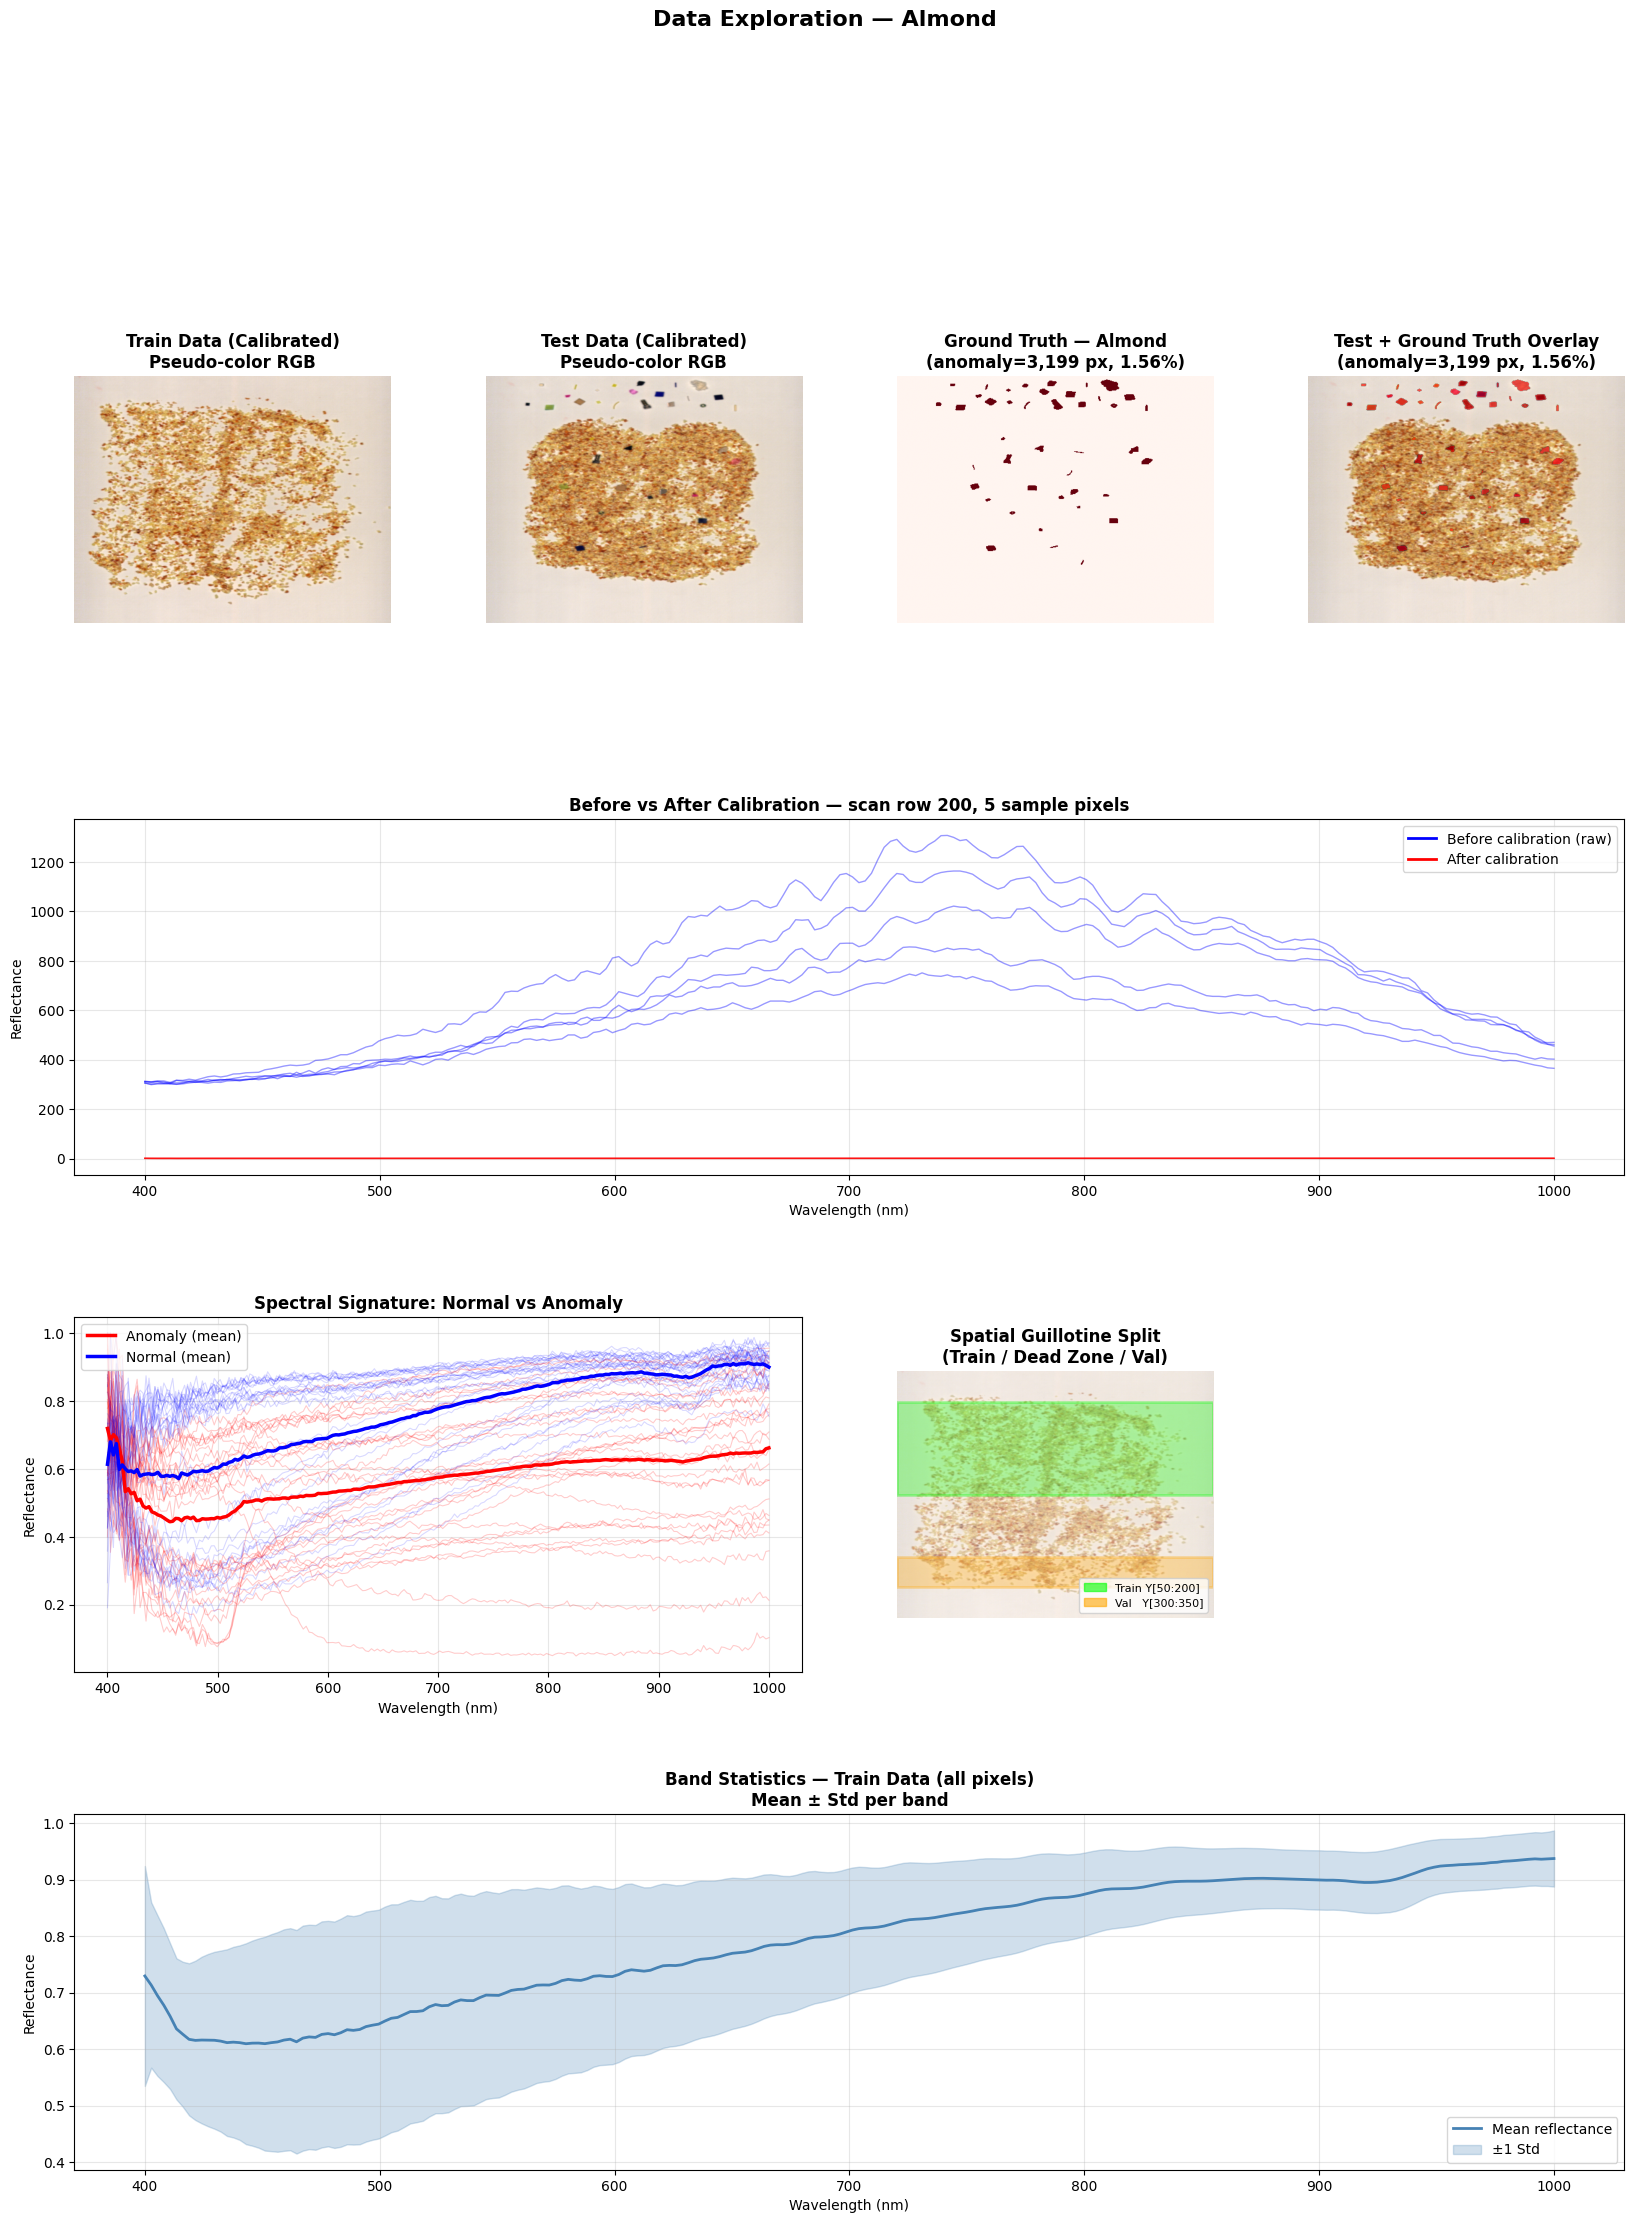

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig = plt.figure(figsize=(20, 24))
gs = fig.add_gridspec(4, 4, hspace=0.4, wspace=0.3)

# ─── Helper: pseudo-color dari HSI ───────────────────────────────────────────
def make_rgb(hsi, r_ratio=0.7, g_ratio=0.45, b_ratio=0.2):
    C = hsi.shape[-1]
    rgb = np.stack([
        hsi[:, :, int(C * r_ratio)],
        hsi[:, :, int(C * g_ratio)],
        hsi[:, :, int(C * b_ratio)],
    ], axis=-1)
    return (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

# ─── 1. Pseudo-color Train (setelah kalibrasi) ───────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.imshow(make_rgb(train_data))
ax.set_title('Train Data (Calibrated)\nPseudo-color RGB', fontweight='bold')
ax.axis('off')

# ─── 2. Pseudo-color Test (setelah kalibrasi) ────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.imshow(make_rgb(test_data))
ax.set_title('Test Data (Calibrated)\nPseudo-color RGB', fontweight='bold')
ax.axis('off')

#just Ground Truth
# plt.figure(figsize=(6, 5))
ax = fig.add_subplot(gs[0, 2])
label_map_temp = binary_labels.reshape(H_test, W_test)
ax.imshow(label_map_temp, cmap='Reds')
ax.set_title(f'Ground Truth — {FOOD_TYPE}\n(anomaly={binary_labels.sum():,} px, {100*binary_labels.mean():.2f}%)',
          fontweight='bold')
# ax.colorbar(fraction=0.046, pad=0.04)
ax.axis('off')
# plt.tight_layout()
# plt.show()

# ─── 3. Ground Truth Overlay ─────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 3])
ax.imshow(make_rgb(test_data))
# gt_overlay = np.zeros((*label_map.shape, 4), dtype=np.float32)
# gt_overlay[label_map == 1] = [1, 0, 0, 0.6]   # merah semi-transparan

gt_overlay = np.zeros((*label_map_temp.shape, 4), dtype=np.float32)
gt_overlay[label_map_temp == 1] = [1, 0, 0, 0.6]
ax.imshow(gt_overlay)
ax.set_title(f'Test + Ground Truth Overlay\n(anomaly={binary_labels.sum():,} px, {100*binary_labels.mean():.2f}%)',
             fontweight='bold')
ax.axis('off')


# ─── 4. Before vs After Kalibrasi (satu scan line) ───────────────────────────
raw_train = load_hsi_data(TRAIN_PATH)   # load ulang tanpa kalibrasi
scan_row  = H // 2                      # ambil baris tengah

ax = fig.add_subplot(gs[1, :])
wavelengths = np.linspace(400, 1000, B)
# ambil 5 pixel acak dari baris tengah
sample_cols = np.linspace(0, W-1, 5, dtype=int)
for col in sample_cols:
    ax.plot(wavelengths, raw_train[scan_row, col, :],
            'b-', alpha=0.4, lw=1)
    ax.plot(wavelengths, train_data[scan_row, col, :],
            'r-', alpha=0.4, lw=1)
ax.plot([], [], 'b-', lw=2, label='Before calibration (raw)')
ax.plot([], [], 'r-', lw=2, label='After calibration')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Reflectance')
ax.set_title(f'Before vs After Calibration — scan row {scan_row}, 5 sample pixels',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# ─── 5. Spectral Signature Normal vs Anomaly ─────────────────────────────────
ax = fig.add_subplot(gs[2, :2])
anomaly_pos = np.argwhere(label_map_temp == 1)
normal_pos  = np.argwhere(label_map_temp == 0)
n_samples   = min(30, len(anomaly_pos), len(normal_pos))

anom_specs   = []
normal_specs = []
for pos in anomaly_pos[np.random.choice(len(anomaly_pos), n_samples, replace=False)]:
    spec = test_data[pos[0], pos[1], :]
    ax.plot(wavelengths, spec, 'r-', alpha=0.2, lw=0.8)
    anom_specs.append(spec)

for pos in normal_pos[np.random.choice(len(normal_pos), n_samples, replace=False)]:
    spec = test_data[pos[0], pos[1], :]
    ax.plot(wavelengths, spec, 'b-', alpha=0.15, lw=0.8)
    normal_specs.append(spec)

# Mean spectrum
ax.plot(wavelengths, np.mean(anom_specs,   axis=0), 'r-', lw=2.5, label='Anomaly (mean)')
ax.plot(wavelengths, np.mean(normal_specs, axis=0), 'b-', lw=2.5, label='Normal (mean)')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Reflectance')
ax.set_title('Spectral Signature: Normal vs Anomaly', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# ─── 6. Spatial Train/Val Split ──────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 2])
ax.imshow(make_rgb(train_data), alpha=0.6)

# Train region box
rect_train = mpatches.Rectangle(
    (0, TRAIN_Y_START), W, TRAIN_Y_END - TRAIN_Y_START,
    linewidth=2, edgecolor='lime', facecolor='lime', alpha=0.3
)
# Val region box
rect_val = mpatches.Rectangle(
    (0, VAL_Y_START), W, VAL_Y_END - VAL_Y_START,
    linewidth=2, edgecolor='orange', facecolor='orange', alpha=0.3
)
ax.add_patch(rect_train)
ax.add_patch(rect_val)
ax.set_title('Spatial Guillotine Split\n(Train / Dead Zone / Val)', fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='lime',   alpha=0.6, label=f'Train Y[{TRAIN_Y_START}:{TRAIN_Y_END}]'),
    mpatches.Patch(color='orange', alpha=0.6, label=f'Val   Y[{VAL_Y_START}:{VAL_Y_END}]'),
], loc='lower right', fontsize=8)
ax.axis('off')

# ─── 7. Band Statistics (mean & std per band) ────────────────────────────────
ax = fig.add_subplot(gs[3, :])
train_flat = train_data.reshape(-1, B)
band_mean  = train_flat.mean(axis=0)
band_std   = train_flat.std(axis=0)

ax.plot(wavelengths, band_mean, 'steelblue', lw=2, label='Mean reflectance')
ax.fill_between(wavelengths,
                band_mean - band_std,
                band_mean + band_std,
                alpha=0.25, color='steelblue', label='±1 Std')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Reflectance')
ax.set_title('Band Statistics — Train Data (all pixels)\nMean ± Std per band', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Data Exploration — {FOOD_TYPE}', fontsize=16, fontweight='bold', y=1.01)
# plt.savefig(f'artifacts/results/{FOOD_TYPE}_data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()




# 4. Utilities (Extract Patch)


In [ ]:
# block_utils.py (GitHub)

def block_search(image_shape, block_size, stride, pad=True):
    H, W = image_shape[:2]
    pad_h = pad_w = 0
    if pad:
        if (H - block_size) % stride != 0:
            pad_h = stride - ((H - block_size) % stride)
        if (W - block_size) % stride != 0:
            pad_w = stride - ((W - block_size) % stride)
    H_pad, W_pad = H + pad_h, W + pad_w
    positions = []
    for i in range(0, H_pad - block_size + 1, stride):
        for j in range(0, W_pad - block_size + 1, stride):
            positions.append((i, j))
    return positions, (H_pad, W_pad)


def block_embedding(image, block_size, stride):
    """
    Ekstrak overlapping blocks dari HSI image (H x W x C).
    Returns: blocks (N, C, block_size, block_size), padded_shape, positions
    """
    H, W = image.shape[0], image.shape[1]
    positions, (H_pad, W_pad) = block_search((H, W), block_size, stride, pad=True)
    pad_h, pad_w = H_pad - H, W_pad - W
    if pad_h > 0 or pad_w > 0:
        image = np.pad(image, ((0, pad_h), (0, pad_w), (0, 0)), mode='constant')
    blocks = []
    for i, j in positions:
        block = image[i:i+block_size, j:j+block_size, :]
        blocks.append(block)
    blocks = np.stack(blocks, axis=0)                         # (N, bs, bs, C)
    blocks = torch.from_numpy(blocks.astype(np.float32)).permute(0, 3, 1, 2)  # (N, C, bs, bs)
    return blocks, (H_pad, W_pad), positions


def block_fold(blocks, image_shape, block_size, stride, positions):
    """Rekonstruksi image dari overlapping blocks dengan averaging."""
    H_orig, W_orig = image_shape
    H_pad = max(i for i, j in positions) + block_size
    W_pad = max(j for i, j in positions) + block_size
    C = blocks.shape[1]
    output = torch.zeros((C, H_pad, W_pad), dtype=blocks.dtype)
    count  = torch.zeros((H_pad, W_pad),    dtype=blocks.dtype)
    for block, (i, j) in zip(blocks, positions):
        output[:, i:i+block_size, j:j+block_size] += block
        count[i:i+block_size, j:j+block_size]     += 1
    count[count == 0] = 1
    output = output / count.unsqueeze(0)
    return output[:, :H_orig, :W_orig]


# Build train/val block datasets
print("Building block datasets...")

train_region = train_data[TRAIN_Y_START:TRAIN_Y_END, :, :]
val_region   = train_data[VAL_Y_START  :VAL_Y_END,   :, :]

train_blocks, train_padded_shape, train_positions = block_embedding(
    train_region, BLOCK_SIZE, STRIDE_PATCH)
val_blocks, val_padded_shape, val_positions = block_embedding(
    val_region, BLOCK_SIZE, STRIDE_PATCH)
test_blocks, test_padded_shape, test_positions = block_embedding(
    test_data, BLOCK_SIZE, STRIDE_PATCH)

print(f"  Train blocks : {train_blocks.shape}")
print(f"  Val   blocks : {val_blocks.shape}")
print(f"  Test  blocks : {test_blocks.shape}")
print(f"  Bands (C)    : {B}")


# Dataset (self-supervised: input = target)
class HSIBlockDataset(Dataset):
    """Input = target = block (self-supervised reconstruction)."""
    def __init__(self, blocks):
        self.blocks = blocks
    def __len__(self):
        return len(self.blocks)
    def __getitem__(self, idx):
        return self.blocks[idx], self.blocks[idx]


train_dataset = HSIBlockDataset(train_blocks)
val_dataset   = HSIBlockDataset(val_blocks)
test_dataset  = HSIBlockDataset(test_blocks)

num_workers = 2
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=num_workers, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

print(f"\nDataLoader:")
print(f"  Train : {len(train_dataset):,} blocks ({len(train_loader)} batches)")
print(f"  Val   : {len(val_dataset):,} blocks ({len(val_loader)} batches)")
print(f"  Test  : {len(test_dataset):,} blocks ({len(test_loader)} batches)")


Building block datasets...
  Train blocks : torch.Size([1134, 224, 16, 16])
  Val   blocks : torch.Size([378, 224, 16, 16])
  Test  blocks : torch.Size([3087, 224, 16, 16])
  Bands (C)    : 224

DataLoader:
  Train : 1,134 blocks (35 batches)
  Val   : 378 blocks (12 batches)
  Test  : 3,087 blocks (97 batches)


# 5.  DMS2F-HAD Architecture


In [ ]:
#  Mamba Import / Fallback
try:
    from mamba_ssm.ops.selective_scan_interface import selective_scan_fn, mamba_inner_fn
    try:
        from causal_conv1d import causal_conv1d_fn, causal_conv1d_update
    except ImportError:
        causal_conv1d_fn = causal_conv1d_update = None
    try:
        from mamba_ssm.ops.triton.selective_state_update import selective_state_update
    except ImportError:
        selective_state_update = None
    try:
        from mamba_ssm.ops.triton.layernorm import RMSNorm, layer_norm_fn, rms_norm_fn
    except ImportError:
        RMSNorm = layer_norm_fn = rms_norm_fn = None
    MAMBA_FULL = True
    print("mamba_ssm ops loaded (CUDA-optimized)")
except ImportError:
    MAMBA_FULL = False
    print("mamba_ssm ops not available — using MambaSimple fallback")


# Mamba (dari mamba_simple.py)
class MambaSimple(nn.Module):
    """Pure-PyTorch Mamba fallback."""
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2,
                 use_fast_path=False, **kwargs):
        super().__init__()
        self.d_inner = int(expand * d_model)
        self.in_proj  = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=d_conv,
                                   groups=self.d_inner, padding=d_conv - 1)
        self.D        = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
    def forward(self, x, **kwargs):
        B, L, _ = x.shape
        residual = x
        x  = self.norm(x)
        xz = self.in_proj(x)
        x_part, z = xz.chunk(2, dim=-1)
        xc = self.conv1d(x_part.transpose(1, 2))[:, :, :L].transpose(1, 2)
        xc = F.silu(xc)
        y  = xc * torch.sigmoid(z) + xc * self.D
        return self.out_proj(y) + residual


def make_mamba(d_model, d_state=64, d_conv=4, expand=2):
    """Factory: gunakan mamba_ssm jika tersedia, fallback ke MambaSimple."""
    if MAMBA_FULL:
        try:
            from mamba_ssm import Mamba
            return Mamba(d_model=d_model, d_state=d_state, d_conv=d_conv,
                         expand=expand, use_fast_path=False)
        except Exception:
            pass
    return MambaSimple(d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand)


# Residual + LayerNorm wrapper (dari model.py)
class Residual_SSMN(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn
    def forward(self, x, **kwargs):
        return self.fn(x, **kwargs) + x

class LayerNormalize_SSMN(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn   = fn
    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)


# mamba_block1 & mamba_block2
class mamba_block1(nn.Module):
    """Spatial Mamba block dengan residual + LayerNorm."""
    def __init__(self, dim, depth):
        super().__init__()
        self.layers = nn.ModuleList([
            Residual_SSMN(LayerNormalize_SSMN(dim, make_mamba(dim, d_state=64)))
            for _ in range(depth)
        ])
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

class mamba_block2(nn.Module):
    """Spectral Mamba block dengan residual + LayerNorm."""
    def __init__(self, dim, depth):
        super().__init__()
        self.layers = nn.ModuleList([
            Residual_SSMN(LayerNormalize_SSMN(dim, make_mamba(dim, d_state=64)))
            for _ in range(depth)
        ])
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


# split_band
def split_band(x, move_num, spec_num):
    """
    Bagi dimensi spektral menjadi segmen overlapping.
    x: (b, c, h, w) → returns (b, n, c, h, w)
    """
    b, c, h, w = x.shape
    slices = []
    for i in range(0, c, move_num):
        if i + spec_num > c:
            sl = x[:, c - spec_num:c, :, :]
        else:
            sl = x[:, i:i + spec_num, :, :]
        slices.append(sl)
    return torch.stack(slices, dim=1)


# RandomMasking
class RandomMasking(nn.Module):
    """
    Masking di dalam model (sesuai model.py GitHub).
    mode: 'full_spectrum' : mask spatial rectangular patch
          'random_channels' : mask sejumlah band secara acak
    """
    def __init__(self, mask_prob=0.5, mask_size=0.2, mode='full_spectrum'):
        super().__init__()
        self.mask_prob = mask_prob
        self.mask_size = mask_size
        self.mode      = mode

    def forward(self, x):
        if not self.training or torch.rand(1) > self.mask_prob:
            return x
        B, C, H, W = x.shape
        mask = torch.ones_like(x)
        if self.mode == 'full_spectrum':
            for b in range(B):
                ph = max(1, int(H * self.mask_size))
                pw = max(1, int(W * self.mask_size))
                i  = torch.randint(0, H - ph + 1, (1,)).item()
                j  = torch.randint(0, W - pw + 1, (1,)).item()
                mask[b, :, i:i+ph, j:j+pw] = 0.
        elif self.mode == 'random_channels':
            num_mask = int(C * self.mask_size)
            idx = torch.randperm(C)[:num_mask]
            mask[:, idx, :, :] = 0.
        return x * mask


# LSSDecoderBlock
class LSSDecoderBlock(nn.Module):
    """
    Decoder block: Mamba (global) + Conv2d 3x3 + Conv2d 5x5 + fuse.
    Sesuai model.py GitHub.
    """
    def __init__(self, channels, hss_depth=2):
        super().__init__()
        self.hss    = mamba_block1(channels, hss_depth)
        self.local3 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.local5 = nn.Conv2d(channels, channels, kernel_size=5, padding=2)
        self.fuse   = nn.Conv2d(channels * 3, channels, kernel_size=1)
        self.act    = nn.GELU()

    def forward(self, x):
        B, C, H, W = x.shape
        g   = rearrange(x, 'b c h w -> b (h w) c')
        g   = self.hss(g)
        g   = rearrange(g, 'b (h w) c -> b c h w', h=H, w=W)
        l3  = self.local3(x)
        l5  = self.local5(x)
        cat = torch.cat([g, l3, l5], dim=1)
        return self.act(self.fuse(cat)) + x


# AnomalyDetectionModel (sesuai model.py GitHub)
class AnomalyDetectionModel(nn.Module):
    """
    DMS2F-HAD: Dual Mamba Spectral-Spatial Fusion.
    Arsitektur persis sesuai model.py dari GitHub.

    mode: 'spatial'  — spatial branch only
          'spectral' — spectral branch only
          'full'     — dual branch + gated fusion
    """
    def __init__(self, in_channels, mode='full', dim=64, depth=1,
                 spec_num=12, spec_rate=0.5, spa_token=16):
        super().__init__()
        self.mode     = mode
        self.spec_num = spec_num
        self.move_num = int(math.ceil(spec_num * spec_rate))
        self.spa_token = spa_token
        self.dim      = dim

        # Preprocessing
        self.preprocess = nn.Sequential(
            nn.Conv2d(in_channels, dim, kernel_size=1),
            nn.BatchNorm2d(dim),
            nn.GELU(),
        )

        # Spatial branch
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(dim),
            nn.GELU(),
        )
        self.spatial_mamba = mamba_block1(dim, depth)

        # Spectral branch
        self.dropout = nn.Dropout(0.1)
        num_patch = (
            math.floor((dim - (spec_num - self.move_num)) / self.move_num) +
            math.ceil(
                (((dim - (spec_num - self.move_num)) % self.move_num)
                 + (spec_num - self.move_num)) / self.move_num
            )
        )
        self.spe_token1 = nn.Sequential(
            nn.Conv3d(1, 1, (1, 1, 7), stride=(1,1,1), padding=(0,0,3)),
            nn.LayerNorm(dim), nn.GELU(),
        )
        self.spe_token2 = nn.Sequential(
            nn.Conv3d(1, 1, (1, 1, 3), stride=(1,1,1), padding=(0,0,1)),
            nn.LayerNorm(dim), nn.GELU(),
        )
        self.spectral_mamba = mamba_block2(spec_num, depth)
        self.nn2 = nn.Sequential(
            nn.Linear(spec_num * num_patch, dim),
            nn.LayerNorm(dim), nn.GELU(),
        )

        # Decoder (2x LSSDecoderBlock)
        self.lss1 = LSSDecoderBlock(dim, hss_depth=2)
        self.lss2 = LSSDecoderBlock(dim, hss_depth=2)
        self.out_conv = nn.Conv2d(dim, in_channels, 1)

        # RandomMasking di dalam model
        self.use_random_mask = True
        self.random_mask     = RandomMasking()

        # Fusion
        self.fusion_fc = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=1), nn.GELU(),
        )
        self.gate_conv = nn.Sequential(
            nn.Conv2d(2 * dim, 1, kernel_size=1), nn.Sigmoid(),
        )

    def forward(self, x):
        b, C, H, W = x.shape

        # RandomMasking (hanya saat training)
        if self.use_random_mask:
            x = self.random_mask(x)

        # Preprocessing: (b, C, H, W) → (b, H, W, dim)
        feat = self.preprocess(x).permute(0, 2, 3, 1)

        #Spatial Branch
        spa_feat     = feat.permute(0, 3, 1, 2)                    # (b, dim, H, W)
        spatial_feat = self.spatial_conv(spa_feat)                  # (b, dim, H, W)
        spatial_feat = self.spatial_mamba(
            rearrange(spatial_feat, 'b c h w -> b (h w) c')
        )                                                           # (b, H*W, dim)
        spatial_feat = rearrange(spatial_feat,
                                  'b (h w) c -> b c h w', h=H, w=W)  # (b, dim, H, W)

        #  Spectral Branch
        x_s = feat.unsqueeze(1)                                     # (b, 1, H, W, dim)
        x_s = self.spe_token1(x_s) + self.spe_token2(x_s) + x_s   # multi-scale spectral
        x_s = self.dropout(x_s).squeeze(1).permute(0, 3, 1, 2)     # (b, dim, H, W)

        # Spatial pooling → (b, dim, 1, 1)
        Patch_pool = nn.AvgPool2d((H, W)).to(x.device)
        x_s = Patch_pool(x_s)                                       # (b, dim, 1, 1)

        # split_band: segmentasi spektral overlapping
        spec_slices = split_band(x_s, self.move_num, self.spec_num)
        bb, nn_seg, cc, hh, ww = spec_slices.shape
        spec_slices = rearrange(spec_slices,
                                 'b n c h w -> (b h w) n c')         # flatten untuk Mamba

        spec_feat = self.spectral_mamba(spec_slices)                 # (b*h*w, n, dim)
        spec_feat = rearrange(spec_feat,
                               '(b h w) n c -> b (n c) h w',
                               h=hh, w=ww).mean(-1)                  # (b, n*dim, 1)
        spec_feat = (
            self.nn2(spec_feat.squeeze(2))
            .unsqueeze(1).unsqueeze(1)
            .permute(0, 3, 1, 2)
        )                                                             # (b, dim, 1, 1)
        spec_feat = spec_feat.view(b, self.dim, 1, 1).expand(b, self.dim, H, W)

        #  Fusion
        if self.mode == 'spatial':
            fused = self.fusion_fc(spatial_feat)
        elif self.mode == 'spectral':
            fused = self.fusion_fc(spec_feat)
        else:   # 'full' — Gated Fusion
            cat       = torch.cat([spatial_feat, spec_feat], dim=1)  # (b, 2*dim, H, W)
            gate      = self.gate_conv(cat)                          # (b, 1, H, W)
            fused_raw = gate * spatial_feat + (1. - gate) * spec_feat
            fused     = self.fusion_fc(fused_raw)

        # Decoder
        z   = self.lss1(fused)
        z   = self.lss2(z)
        out = self.out_conv(z)                                       # (b, C, H, W)
        return out, fused

    @torch.no_grad()
    def anomaly_score_patch(self, x):
        """Reconstruction error per pixel (mean atas bands)."""
        self.eval()
        recon, _ = self.forward(x)
        return ((x - recon) ** 2).mean(dim=1)   # (b, H, W)


#  Smoke-test
model = AnomalyDetectionModel(
    in_channels=B, mode=MODE, dim=DIM, depth=DEPTH,
    spec_num=SPEC_NUM, spec_rate=SPEC_RATE, spa_token=SPA_TOKEN
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model DMS2F-HAD (mode='{MODE}')")
print(f"  Parameters : {n_params:,}  ({n_params/1e6:.2f} M)")

x_dummy = torch.randn(2, B, BLOCK_SIZE, BLOCK_SIZE).to(device)
out, fused = model(x_dummy)
print(f"  Input  : {x_dummy.shape}")
print(f"  Output : {out.shape}")
print(f"  Fused  : {fused.shape}")
print("Model OK!")


mamba_ssm ops loaded (CUDA-optimized)
Model DMS2F-HAD (mode='full')
  Parameters : 644,541  (0.64 M)
  Input  : torch.Size([2, 224, 16, 16])
  Output : torch.Size([2, 224, 16, 16])
  Fused  : torch.Size([2, 64, 16, 16])
Model OK!


# 6. FLOPs & Parameter Counter

In [ ]:
!pip install thop

In [ ]:
from thop import profile as thop_profile

def compute_flops(model, in_channels, block_size, device):
    model.eval()
    dummy = torch.randn(1, in_channels, block_size, block_size).to(device)
    try:
        flops, params = thop_profile(model, inputs=(dummy,), verbose=False)
        return flops, params
    except Exception as e:
        print(f"  FLOPs estimation failed: {e}")
        return 0, sum(p.numel() for p in model.parameters())

flops, _ = compute_flops(model, B, BLOCK_SIZE, device)
print(f"FLOPs per patch : {flops/1e6:.2f} MFLOPs")
print(f"Parameters      : {n_params:,}")


FLOPs per patch : 128.37 MFLOPs
Parameters      : 644,541


# 7. Training

In [ ]:
import torch.optim as optim

[TRAIN] Trainable params: 644,541
[TRAIN] Universal Early Stopping: patience=50, min_delta=0.0001
  Tidak ada checkpoint — mulai dari epoch 1
Training 'Almond_dms2f_full' | epoch 0→500 (max) | device=cuda


  Ep    0 | train=0.29519 | val=0.08703 | MSE=0.25625 | L1=0.38941 | ROC-AUC=0.4757 | PR-AUC=0.2393 | lr=5.0e-04 | 2.6s
New best ROC-AUC=0.4757 | PR-AUC=0.2393 @ epoch 0
  [Checkpoint saved @ epoch 0]


  Ep    1 | train=0.02591 | val=0.02861 | MSE=0.01669 | L1=0.09220 | ROC-AUC=0.7015 | PR-AUC=0.3662 | lr=5.0e-04 | 1.9s
New best ROC-AUC=0.7015 | PR-AUC=0.3662 @ epoch 1


New best ROC-AUC=0.7376 | PR-AUC=0.4392 @ epoch 2
  [EarlyStopping] Patience 1/50 (Best: 0.02861)


  [EarlyStopping] Patience 2/50 (Best: 0.02861)


...

  [EarlyStopping] Patience 46/50 (Best: 0.00353)


  [EarlyStopping] Patience 47/50 (Best: 0.00353)


  [EarlyStopping] Patience 48/50 (Best: 0.00353)


  [EarlyStopping] Patience 49/50 (Best: 0.00353)


  Ep   90 | train=0.00290 | val=0.00494 | MSE=0.00109 | L1=0.01806 | ROC-AUC=0.8161 | PR-AUC=0.6003 | lr=4.6e-04 | 1.9s
  [Checkpoint saved @ epoch 90]
  [EarlyStopping] Patience 50/50 (Best: 0.00353)

  Convergence reached at epoch 90. Training stopped.

Training Done (early stopping) @ epoch 90
Best ROC-AUC: 0.9294 | Best PR-AUC: 0.6400 | Time: 447.2s


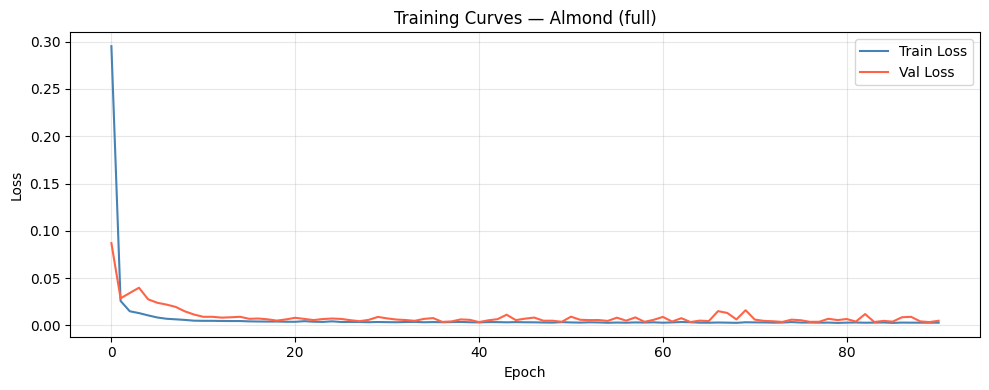

In [ ]:
import shutil

# Universal Early Stopping
class UniversalEarlyStopping:
    """
    Monitors validation reconstruction loss to prevent Identity Mapping.

    Args:
        patience (int)  : How many epochs to wait after last meaningful improvement.
        min_delta (float): Minimum absolute change to qualify as improvement.
    """
    def __init__(self, patience=50, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            print(f"  [EarlyStopping] Patience {self.counter}/{self.patience} "
                  f"(Best: {self.best_loss:.5f})")
            if self.counter >= self.patience:
                self.early_stop = True


# Loss (sesuai train.py GitHub: MSE + 0.1 * L1)
mse_crit = nn.MSELoss()
l1_crit  = nn.L1Loss()

def compute_loss(recon, target):
    mse  = mse_crit(recon, target)
    l1   = l1_crit(recon, target)
    return mse + 0.1 * l1, mse, l1


# Validation
def run_val(model, loader, device):
    model.eval()
    total = 0.
    with torch.no_grad():
        for blocks, targets in loader:
            blocks  = blocks.to(device)
            targets = targets.to(device)
            recon, _ = model(blocks)
            loss, _, _ = compute_loss(recon, targets)
            total += loss.item()
    return total / len(loader)


#  Checkpoint helpers
def save_checkpoint(model, optimizer, scheduler, epoch, history,
                    best_auc, best_pr_auc, exp_name, drive_ckpt_dir,
                    early_stopper=None):
    ckpt = {
        'epoch':       epoch,
        'model_state': model.state_dict(),
        'optim_state': optimizer.state_dict(),
        'sched_state': scheduler.state_dict(),
        'history':     history,
        'best_auc':    best_auc,
        'best_pr_auc': best_pr_auc,
    }
    # Save early stopper state juga supaya resume konsisten
    if early_stopper is not None:
        ckpt['es_counter']    = early_stopper.counter
        ckpt['es_best_loss']  = early_stopper.best_loss
        ckpt['es_early_stop'] = early_stopper.early_stop

    local = f'artifacts/checkpoints/{exp_name}_resume.pt'
    drive = os.path.join(drive_ckpt_dir, f'{exp_name}_resume.pt')
    torch.save(ckpt, local)
    shutil.copy2(local, drive)


def load_checkpoint(exp_name, model, optimizer, scheduler, drive_ckpt_dir,
                    early_stopper=None):
    empty = ({'train_loss': [], 'val_loss': [],
              'val_roc_auc': [], 'val_pr_auc': []}, 0, 0.0, 0.0)
    drive = os.path.join(drive_ckpt_dir, f'{exp_name}_resume.pt')
    local = f'artifacts/checkpoints/{exp_name}_resume.pt'
    path  = None
    if   os.path.exists(drive): path = drive; print(f"  Resume dari Drive: {drive}")
    elif os.path.exists(local): path = local; print(f"  Resume dari local: {local}")
    else:
        print("  Tidak ada checkpoint — mulai dari epoch 1")
        return empty

    ckpt = torch.load(path, map_location='cpu', weights_only=False)
    model.load_state_dict(ckpt['model_state'], strict=False)
    optimizer.load_state_dict(ckpt['optim_state'])
    scheduler.load_state_dict(ckpt['sched_state'])
    start = ckpt['epoch'] + 1
    best_pr_auc = ckpt.get('best_pr_auc', 0.0)

    # Restore early stopper state kalau ada
    if early_stopper is not None:
        early_stopper.counter    = ckpt.get('es_counter', 0)
        early_stopper.best_loss  = ckpt.get('es_best_loss', np.inf)
        early_stopper.early_stop = ckpt.get('es_early_stop', False)
        if early_stopper.best_loss != np.inf:
            print(f"  EarlyStopping restored: counter={early_stopper.counter}, "
                  f"best_loss={early_stopper.best_loss:.5f}")

    print(f"  Resume dari epoch {start}  (best_auc={ckpt['best_auc']:.4f}, "
          f"best_pr_auc={best_pr_auc:.4f})")
    return ckpt['history'], start, ckpt['best_auc'], best_pr_auc


# Training Loop dengan Universal Early Stopping
def train_dms2f(model, train_loader, val_loader, test_blocks, test_positions,
                epochs=500, lr=5e-4, wd=1e-4, device='cuda',
                exp_name='dms2f', drive_ckpt_dir=None, ckpt_every=5,
                patience=50, min_delta=1e-4):
    """
    Training dengan Universal Early Stopping:
    - Monitor validation loss (reconstruction)
    - Stop saat val_loss flatline (patience epoch tanpa improvement >= min_delta)
    - `epochs` berfungsi sebagai upper limit (default 500)
    """

    model = model.to(device)

    for p in model.parameters(): p.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[TRAIN] Trainable params: {trainable:,}")
    print(f"[TRAIN] Universal Early Stopping: patience={patience}, min_delta={min_delta}")

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    # CosineAnnealingLR dengan T_max=epochs (upper limit), early stopping bisa berhenti lebih dulu
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr * 1e-2)

    # Init early stopper
    early_stopper = UniversalEarlyStopping(patience=patience, min_delta=min_delta)

    history, start_epoch, best_auc, best_pr_auc = load_checkpoint(
        exp_name, model, optimizer, scheduler,
        drive_ckpt_dir or 'artifacts/checkpoints',
        early_stopper=early_stopper
    )

    if not history: history = {
        'train_loss': [], 'val_loss': [],
        'val_roc_auc': [], 'val_pr_auc': []
    }
    history.setdefault('val_roc_auc', [])
    history.setdefault('val_pr_auc', [])

    if early_stopper.early_stop:
        print(f"  Training sudah early-stopped sebelumnya. Skip.")
        return model, history, 0.

    if start_epoch > epochs:
        print(f"  Training Done (epoch {start_epoch-1}/{epochs})")
        return model, history, 0.

    t_start = time.time()
    print(f"Training '{exp_name}' | epoch {start_epoch}→{epochs} (max) | device={device}")

    for epoch in range(start_epoch, epochs + 1):
        model.train()
        running, mse_sum, l1_sum = 0., 0., 0.
        ep_start = time.time()

        pbar = tqdm(train_loader, desc=f'Ep {epoch:3d}/{epochs}', leave=False)
        for blocks, targets in pbar:
            blocks  = blocks.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            recon, _ = model(blocks)
            loss, mse, l1 = compute_loss(recon, targets)
            loss.backward()
            optimizer.step()
            running += loss.item() * blocks.size(0)
            mse_sum += mse.item()  * blocks.size(0)
            l1_sum  += l1.item()   * blocks.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.4f}',
                              'lr':   f'{scheduler.get_last_lr()[0]:.1e}'})

        n = len(train_loader.dataset)
        avg_train = running / n
        avg_val   = run_val(model, val_loader, device)
        scheduler.step()

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)

        ep_time = time.time() - ep_start

        # Evaluasi ROC-AUC dan PR-AUC pada test set
        model.eval()
        recs = []
        with torch.no_grad():
            for blk, _ in DataLoader(test_dataset, batch_size=BATCH_SIZE,
                                      num_workers=2, pin_memory=True):
                out, _ = model(blk.to(device))
                recs.append(out.cpu())
        recs      = torch.cat(recs, dim=0)
        recon_map = block_fold(recs, (H_test, W_test),
                                BLOCK_SIZE, STRIDE_PATCH, test_positions)
        orig_map  = torch.tensor(test_data.astype(np.float32)).permute(2, 0, 1)
        diff      = recon_map - orig_map
        res_map   = torch.norm(diff, dim=0).numpy()
        gt_flat    = binary_labels.astype(int)
        val_auc    = roc_auc_score(gt_flat, res_map.ravel())
        prec_ep, rec_ep, _ = precision_recall_curve(gt_flat, res_map.ravel())
        val_pr_auc = auc(rec_ep, prec_ep)
        history['val_roc_auc'].append(val_auc)
        history['val_pr_auc'].append(val_pr_auc)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Ep {epoch:4d} | train={avg_train:.5f} | val={avg_val:.5f} | "
                  f"MSE={mse_sum/n:.5f} | L1={l1_sum/n:.5f} | "
                  f"ROC-AUC={val_auc:.4f} | PR-AUC={val_pr_auc:.4f} | "
                  f"lr={scheduler.get_last_lr()[0]:.1e} | {ep_time:.1f}s")

        # Save best model
        if val_auc > best_auc:
            best_auc    = val_auc
            best_pr_auc = val_pr_auc
            best = {'epoch': epoch, 'state_dict': model.state_dict(),
                    'auc': best_auc, 'pr_auc': best_pr_auc}
            local_best = f'artifacts/models/{exp_name}_best.pt'
            torch.save(best, local_best)
            shutil.copy2(local_best,
                         os.path.join(DRIVE_MODEL_DIR, f'{exp_name}_best.pt'))
            print(f"New best ROC-AUC={best_auc:.4f} | PR-AUC={best_pr_auc:.4f} @ epoch {epoch}")

        # Periodic checkpoint (tiap ckpt_every epoch)
        if epoch % ckpt_every == 0:
            save_checkpoint(model, optimizer, scheduler, epoch, history,
                            best_auc, best_pr_auc, exp_name,
                            drive_ckpt_dir or 'artifacts/checkpoints',
                            early_stopper=early_stopper)
            print(f"  [Checkpoint saved @ epoch {epoch}]")

        # Universal Early Stopping check (monitor val reconstruction loss)
        early_stopper(avg_val)
        if early_stopper.early_stop:
            print(f"\n  Convergence reached at epoch {epoch}. Training stopped.")
            # Simpan final checkpoint sebelum break
            save_checkpoint(model, optimizer, scheduler, epoch, history,
                            best_auc, best_pr_auc, exp_name,
                            drive_ckpt_dir or 'artifacts/checkpoints',
                            early_stopper=early_stopper)
            break

    # Final checkpoint kalau training habis epoch (bukan dari early stop)
    if not early_stopper.early_stop:
        save_checkpoint(model, optimizer, scheduler, epoch, history,
                        best_auc, best_pr_auc, exp_name,
                        drive_ckpt_dir or 'artifacts/checkpoints',
                        early_stopper=early_stopper)

    training_time = time.time() - t_start
    stop_reason = "early stopping" if early_stopper.early_stop else "epoch limit"
    print(f"\nTraining Done ({stop_reason}) @ epoch {epoch}")
    print(f"Best ROC-AUC: {best_auc:.4f} | Best PR-AUC: {best_pr_auc:.4f} | Time: {training_time:.1f}s")
    return model, history, training_time


# Run Training
if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats(device)

EXP_NAME = f'{FOOD_TYPE}_dms2f_{MODE}'
model, history, training_time = train_dms2f(
    model, train_loader, val_loader,
    test_blocks, test_positions,
    epochs=EPOCHS, lr=LR, wd=WEIGHT_DECAY,
    device=str(device), exp_name=EXP_NAME,
    drive_ckpt_dir=DRIVE_CKPT_DIR, ckpt_every=5,
    patience=50, min_delta=1e-4
)

# Plot training loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train Loss', color='steelblue')
ax.plot(history['val_loss'],   label='Val Loss',   color='tomato')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title(f'Training Curves — {FOOD_TYPE} ({MODE})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'artifacts/results/{EXP_NAME}_training_curves.png', dpi=150)
plt.show()


## 8. Inference & Evaluasi

In [ ]:
# Load best checkpoint
ckpt_path = f'artifacts/models/{EXP_NAME}_best.pt'
drive_ckpt_best = os.path.join(DRIVE_MODEL_DIR, f'{EXP_NAME}_best.pt')

if os.path.exists(drive_ckpt_best):
    ckpt = torch.load(drive_ckpt_best, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['state_dict'], strict=False)
    print(f"Loaded best model: epoch {ckpt['epoch']}, AUC={ckpt['auc']:.4f}")
elif os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['state_dict'], strict=False)
    print(f"Loaded best model (local): epoch {ckpt['epoch']}, AUC={ckpt['auc']:.4f}")
else:
    print("Checkpoint tidak ditemukan — pakai model terakhir")

#  Reconstruct seluruh test image via block_fold
print("\nRunning inference on test data...")
infer_start = time.time()

model.eval()
recs = []
with torch.no_grad():
    for blk, _ in tqdm(DataLoader(test_dataset, batch_size=BATCH_SIZE,
                                   num_workers=2, pin_memory=True),
                        desc='Inference'):
        out, _ = model(blk.to(device))
        recs.append(out.cpu())

recs      = torch.cat(recs, dim=0)                                    # (N, C, bs, bs)
recon_map = block_fold(recs, (H_test, W_test),
                        BLOCK_SIZE, STRIDE_PATCH, test_positions)      # (C, H, W)
orig_map  = torch.tensor(test_data.astype(np.float32)).permute(2,0,1) # (C, H, W)

diff    = recon_map - orig_map
res_map = torch.norm(diff, dim=0).numpy()   # (H, W) — norm residual per pixel

infer_time = time.time() - infer_start
print(f"  Inference time: {infer_time:.2f}s")

# Metrics
# Rank normalization
score_flat = res_map.ravel()
rank_scores = rankdata(score_flat, method='average') / len(score_flat)
score_norm  = rank_scores.reshape(H_test, W_test)
score_1d    = score_norm.ravel()
label_1d    = label_map_temp.ravel().astype(int)
label_map   = label_map_temp

roc_auc  = roc_auc_score(label_1d, score_1d)
prec, rec, _  = precision_recall_curve(label_1d, score_1d)
pr_auc   = auc(rec, prec)
fpr, tpr, _   = roc_curve(label_1d, score_1d)
baseline_ap   = label_1d.mean()

max_vram_gb = 0.
if torch.cuda.is_available():
    max_vram_gb = torch.cuda.max_memory_allocated(device) / (1024**3)

print(f"\n{'='*50}")
print(f"  {FOOD_TYPE} — DMS2F-HAD ({MODE})")
print(f"  ROC-AUC : {roc_auc:.4f}")
print(f"  PR-AUC  : {pr_auc:.4f}")
if max_vram_gb > 0: print(f"  Peak VRAM: {max_vram_gb:.2f} GB")
print(f"{'='*50}")

# Simpan inference results untuk visualisasi kapan saja
save_dict = {
    'score_norm':    score_norm,
    'score_1d':      score_1d,
    'binary_labels': binary_labels,
    'label_map':     label_map_temp,
    'test_data':     test_data,
    'res_map':       res_map,
    'roc_auc':       roc_auc,
    'pr_auc':        pr_auc,
    'food_type':     FOOD_TYPE,
    'H_test':        H_test,
    'W_test':        W_test,
}
npz_local = f'artifacts/results/{EXP_NAME}_inference_results.npz'
npz_drive = os.path.join(DRIVE_RESULT_DIR, f'{EXP_NAME}_inference_results.npz')
np.savez_compressed(npz_local, **save_dict)
shutil.copy2(npz_local, npz_drive)
print(f"\nInference results disimpan: {npz_drive}")


Loaded best model: epoch 10, AUC=0.9294

Running inference on test data...


Inference: 100%|██████████| 97/97 [00:02<00:00, 44.17it/s]


  Inference time: 2.93s

  Almond — DMS2F-HAD (full)
  ROC-AUC : 0.9294
  PR-AUC  : 0.6400
  Peak VRAM: 0.39 GB

Inference results disimpan: /content/drive/MyDrive/Master/Research/HAD-Experiment/Result-2/results/Almond_dms2f_full_inference_results.npz


#9. Save Result to Google Drive

In [ ]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

#  FLOPs final
flops, _ = compute_flops(model, B, BLOCK_SIZE, device)

# Hitung parameter count yang benar (sum of p.numel())
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Cleanup buffer thop supaya tidak ikut tersimpan di checkpoint
for m in model.modules():
    for attr in ['total_ops', 'total_params']:
        if hasattr(m, attr):
            delattr(m, attr)
print(f"thop buffers cleaned | Parameters: {n_params:,}")

# Result row
result_row = {
    'Timestamp':          datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Food Type':          FOOD_TYPE,
    'Model':              'DMS2F-HAD',
    'Mode':               MODE,
    'Protocol':           'Universal Early Stopping (p=50, δ=1e-4)',
    'ROC-AUC':            round(roc_auc, 4),
    'PR-AUC (AUPR)':      round(pr_auc,  4),
    'Training Time (s)':  round(training_time, 2),
    'Inference Time (s)': round(infer_time, 2),
    'FLOPs (MFLOPs)':     round(flops / 1e6, 2),
    'Parameters':         int(n_params),
    'Epochs':             EPOCHS,
    'Batch Size':         BATCH_SIZE,
    'LR':                 LR,
    'Dim':                DIM,
    'Depth':              DEPTH,
    'Spec Num':           SPEC_NUM,
    'Spec Rate':          SPEC_RATE,
    'Block Size':         BLOCK_SIZE,
    'Stride':             STRIDE_PATCH,
    'Peak VRAM (GB)':     round(max_vram_gb, 3),
    'GPU':                torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
    'Bands':              B,
    'Anomaly Pixels':     int(binary_labels.sum()),
    'Total Pixels':       int(len(binary_labels)),
    'Anomaly Ratio (%)':  round(100 * binary_labels.mean(), 4),
}

print("Result row:")
for k, v in result_row.items():
    print(f"  {k:<25}: {v}")

#  Excel helpers
hdr_fill  = PatternFill('solid', fgColor='1F4E79')
hdr_font  = Font(bold=True, color='FFFFFF', size=11)
alt_fill  = PatternFill('solid', fgColor='D6E4F0')
c_align   = Alignment(horizontal='center', vertical='center', wrap_text=True)
thin      = Border(*[Side(style='thin')]*0,
                   left=Side(style='thin'), right=Side(style='thin'),
                   top=Side(style='thin'),  bottom=Side(style='thin'))

def style_header(ws, n):
    for col in range(1, n+1):
        c = ws.cell(row=1, column=col)
        c.fill=hdr_fill; c.font=hdr_font; c.alignment=c_align; c.border=thin

def style_row(ws, row, n, alt=False):
    for col in range(1, n+1):
        c = ws.cell(row=row, column=col)
        if alt: c.fill = alt_fill
        c.alignment=c_align; c.border=thin

def auto_width(ws):
    for col in ws.columns:
        w = max((len(str(c.value or '')) for c in col), default=10)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(w+4, 40)

#  Main Results Excel (append)
EXCEL_DRIVE = os.path.join(DRIVE_RESULT_DIR, 'DMS2F_HAD_Results.xlsx')
EXCEL_LOCAL = 'artifacts/results/DMS2F_HAD_Results.xlsx'

headers = list(result_row.keys())
values  = list(result_row.values())

if os.path.exists(EXCEL_DRIVE):
    shutil.copy2(EXCEL_DRIVE, EXCEL_LOCAL)
    wb = openpyxl.load_workbook(EXCEL_LOCAL)
    ws = wb.active
    next_row = ws.max_row + 1
    print(f"\nAppend ke Excel (baris {next_row})")
else:
    wb = openpyxl.Workbook()
    ws = wb.active; ws.title = 'Results'
    ws.append(headers)
    style_header(ws, len(headers))
    ws.row_dimensions[1].height = 30
    next_row = 2
    print("\nMembuat Excel baru")

ws.append(values)
style_row(ws, next_row, len(headers), alt=(next_row % 2 == 0))
ws.row_dimensions[next_row].height = 20
auto_width(ws)
wb.save(EXCEL_LOCAL)
shutil.copy2(EXCEL_LOCAL, EXCEL_DRIVE)
print(f"Excel disimpan: {EXCEL_DRIVE}")

#  Model Summary Excel (file terpisah)
SUMM_DRIVE = os.path.join(DRIVE_RESULT_DIR, f'{EXP_NAME}_ModelSummary.xlsx')
SUMM_LOCAL = f'artifacts/results/{EXP_NAME}_ModelSummary.xlsx'

wb_s = openpyxl.Workbook()

# Sheet 1: Architecture
ws_a = wb_s.active; ws_a.title = 'Architecture'
ws_a.append(['Component', 'Detail', 'Value'])
style_header(ws_a, 3)
arch = [
    ('Model',        'Name',              'DMS2F-HAD'),
    ('Model',        'Mode',              MODE),
    ('Model',        'Parameters',        f'{n_params:,}'),
    ('Model',        'FLOPs per patch',   f'{flops/1e6:.2f} MFLOPs'),
    ('Preprocess',   'Conv2d(C→dim)',      f'Conv2d({B},{DIM},k=1)+BN+GELU'),
    ('Spatial Enc',  'Conv2d',            f'Conv2d({DIM},{DIM},k=3,p=1)+BN+GELU'),
    ('Spatial Enc',  'mamba_block1',      f'{DEPTH}x Mamba(d_model={DIM},d_state=64)'),
    ('Spatial Enc',  'Input seq',         f'(b, H*W, {DIM})'),
    ('Spectral Enc', 'spe_token1',        'Conv3d(1,1,(1,1,7)) — scale 7'),
    ('Spectral Enc', 'spe_token2',        'Conv3d(1,1,(1,1,3)) — scale 3'),
    ('Spectral Enc', 'AvgPool2d',         f'Pool spatial → (b,{DIM},1,1)'),
    ('Spectral Enc', 'split_band',        f'spec_num={SPEC_NUM}, move_num={int(math.ceil(SPEC_NUM*SPEC_RATE))}'),
    ('Spectral Enc', 'mamba_block2',      f'{DEPTH}x Mamba(d_model={SPEC_NUM},d_state=64)'),
    ('Spectral Enc', 'nn2 Linear',        f'Linear({SPEC_NUM}*num_patch, {DIM})'),
    ('RandomMasking','mode',              'full_spectrum (spatial patch mask)'),
    ('RandomMasking','mask_prob',         '0.5'),
    ('RandomMasking','mask_size',         '0.2'),
    ('Gated Fusion', 'gate_conv',         f'Conv2d({DIM*2},1,k=1)+Sigmoid'),
    ('Gated Fusion', 'fusion',            'gate*spatial + (1-gate)*spectral'),
    ('Decoder lss1', 'LSSDecoderBlock',   'Mamba(hss_depth=2)+Conv3+Conv5+fuse'),
    ('Decoder lss2', 'LSSDecoderBlock',   'Mamba(hss_depth=2)+Conv3+Conv5+fuse'),
    ('Decoder out',  'out_conv',          f'Conv2d({DIM},{B},k=1)'),
    ('Training',     'Optimizer',         'Adam'),
    ('Training',     'Scheduler',         'CosineAnnealingLR'),
    ('Training',     'Loss',              'MSE + 0.1*L1'),
    ('Training',     'Block size',        f'{BLOCK_SIZE}x{BLOCK_SIZE}, stride={STRIDE_PATCH}'),
    ('Training',     'Epochs',            str(EPOCHS)),
    ('Dataset',      'Food type',         FOOD_TYPE),
    ('Dataset',      'Format',            '.hdr (ENVI Hyperspectral)'),
    ('Dataset',      'Dimensions',        f'{H}x{W}x{B}'),
    ('Dataset',      'Calibration',       'White/Dark Reference'),
    ('Dataset',      'Split',             f'Train Y[{TRAIN_Y_START}:{TRAIN_Y_END}], Val Y[{VAL_Y_START}:{VAL_Y_END}]'),
]
for i, row in enumerate(arch, 2):
    ws_a.append(list(row))
    style_row(ws_a, i, 3, alt=(i%2==0))
auto_width(ws_a)

# Sheet 2: Training History
ws_h = wb_s.create_sheet('Training History')
ws_h.append(['Epoch', 'Train Loss', 'Val Loss', 'ROC-AUC', 'PR-AUC'])
style_header(ws_h, 5)
for i, (tr, vl, ra, pa) in enumerate(zip(
    history['train_loss'], history['val_loss'],
    history['val_roc_auc'], history['val_pr_auc']), 2):
    ws_h.append([i-1, round(tr,6), round(vl,6), round(ra,4), round(pa,4)])
    style_row(ws_h, i, 5, alt=(i%2==0))
auto_width(ws_h)


# Sheet 3: Performance
ws_p = wb_s.create_sheet('Performance')
ws_p.append(['Metric', 'Value'])
style_header(ws_p, 2)
perf = [
    ('ROC-AUC',           f'{roc_auc:.4f}'),
    ('PR-AUC (AUPR)',      f'{pr_auc:.4f}'),
    ('Training Time (s)', f'{training_time:.2f}'),
    ('Inference Time (s)',f'{infer_time:.2f}'),
    ('FLOPs (MFLOPs)',    f'{flops/1e6:.2f}'),
    ('Parameters',        f'{n_params:,}'),
    ('Peak VRAM (GB)',     f'{max_vram_gb:.3f}'),
    ('GPU',               torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'),
    ('Anomaly Pixels',    f'{binary_labels.sum():,}'),
    ('Total Pixels',      f'{len(binary_labels):,}'),
    ('Anomaly Ratio (%)', f'{100*binary_labels.mean():.4f}'),
]
for i, row in enumerate(perf, 2):
    ws_p.append(list(row)); style_row(ws_p, i, 2, alt=(i%2==0))
auto_width(ws_p)

wb_s.save(SUMM_LOCAL)
shutil.copy2(SUMM_LOCAL, SUMM_DRIVE)
print(f"Model summary: {SUMM_DRIVE}")

# ─── Sync semua figures & models ke Drive ────────────────────────────────────
for fname in os.listdir('artifacts/results'):
    shutil.copy2(os.path.join('artifacts/results', fname),
                 os.path.join(DRIVE_RESULT_DIR, fname))
for fname in os.listdir('artifacts/models'):
    shutil.copy2(os.path.join('artifacts/models', fname),
                 os.path.join(DRIVE_MODEL_DIR, fname))

print(f"\nSemua file tersinkronisasi ke Drive:")
print(f"  {DRIVE_RESULT_DIR}")
print(f"  {DRIVE_MODEL_DIR}")


thop buffers cleaned | Parameters: 644,541
Result row:
  Timestamp                : 2026-04-22 06:00:53
  Food Type                : Almond
  Model                    : DMS2F-HAD
  Mode                     : full
  Protocol                 : Universal Early Stopping (p=50, δ=1e-4)
  ROC-AUC                  : 0.9294
  PR-AUC (AUPR)            : 0.64
  Training Time (s)        : 447.16
  Inference Time (s)       : 2.93
  FLOPs (MFLOPs)           : 128.37
  Parameters               : 644541
  Epochs                   : 500
  Batch Size               : 32
  LR                       : 0.0005
  Dim                      : 64
  Depth                    : 1
  Spec Num                 : 12
  Spec Rate                : 0.5
  Block Size               : 16
  Stride                   : 8
  Peak VRAM (GB)           : 0.393
  GPU                      : NVIDIA A100-SXM4-40GB
  Bands                    : 224
  Anomaly Pixels           : 3199
  Total Pixels             : 204800
  Anomaly Ratio (%)      

# 10. Ablation Studies


--- Mode: Spatial Branch Only ---
[TRAIN] Trainable params: 644,541
[TRAIN] Universal Early Stopping: patience=50, min_delta=0.0001
  Tidak ada checkpoint — mulai dari epoch 1
Training 'Almond_dms2f_spatial' | epoch 0→500 (max) | device=cuda


  Ep    0 | train=0.33505 | val=0.11498 | MSE=0.29166 | L1=0.43390 | ROC-AUC=0.2564 | PR-AUC=0.0660 | lr=5.0e-04 | 1.7s
New best ROC-AUC=0.2564 | PR-AUC=0.0660 @ epoch 0
  [Checkpoint saved @ epoch 0]


  Ep    1 | train=0.03479 | val=0.03733 | MSE=0.02410 | L1=0.10695 | ROC-AUC=0.7681 | PR-AUC=0.3564 | lr=5.0e-04 | 1.8s
New best ROC-AUC=0.7681 | PR-AUC=0.3564 @ epoch 1


New best ROC-AUC=0.7777 | PR-AUC=0.3947 @ epoch 3


New best ROC-AUC=0.8375 | PR-AUC=0.4465 @ epoch 4


...

  [EarlyStopping] Patience 46/50 (Best: 0.04519)


  [EarlyStopping] Patience 47/50 (Best: 0.04519)


  [Checkpoint saved @ epoch 135]
  [EarlyStopping] Patience 48/50 (Best: 0.04519)


  [EarlyStopping] Patience 49/50 (Best: 0.04519)


  [EarlyStopping] Patience 50/50 (Best: 0.04519)

  Convergence reached at epoch 137. Training stopped.

Training Done (early stopping) @ epoch 137
Best ROC-AUC: 0.9028 | Best PR-AUC: 0.3834 | Time: 687.3s
  Loaded BEST model: epoch 41, ROC-AUC=0.9028
  ROC-AUC: 0.9028

--- Mode: Both Branches (Gated Fusion) ---
[TRAIN] Trainable params: 644,541
[TRAIN] Universal Early Stopping: patience=50, min_delta=0.0001
  Resume dari Drive: /content/drive/MyDrive/Master/Research/HAD-Experiment/Result-2/checkpoints/Almond_dms2f_full_resume.pt
  EarlyStopping restored: counter=50, best_loss=0.00353
  Resume dari epoch 91  (best_auc=0.9294, best_pr_auc=0.6400)
  Training sudah early-stopped sebelumnya. Skip.
  Loaded BEST model: epoch 10, ROC-AUC=0.9294
  ROC-AUC: 0.9294


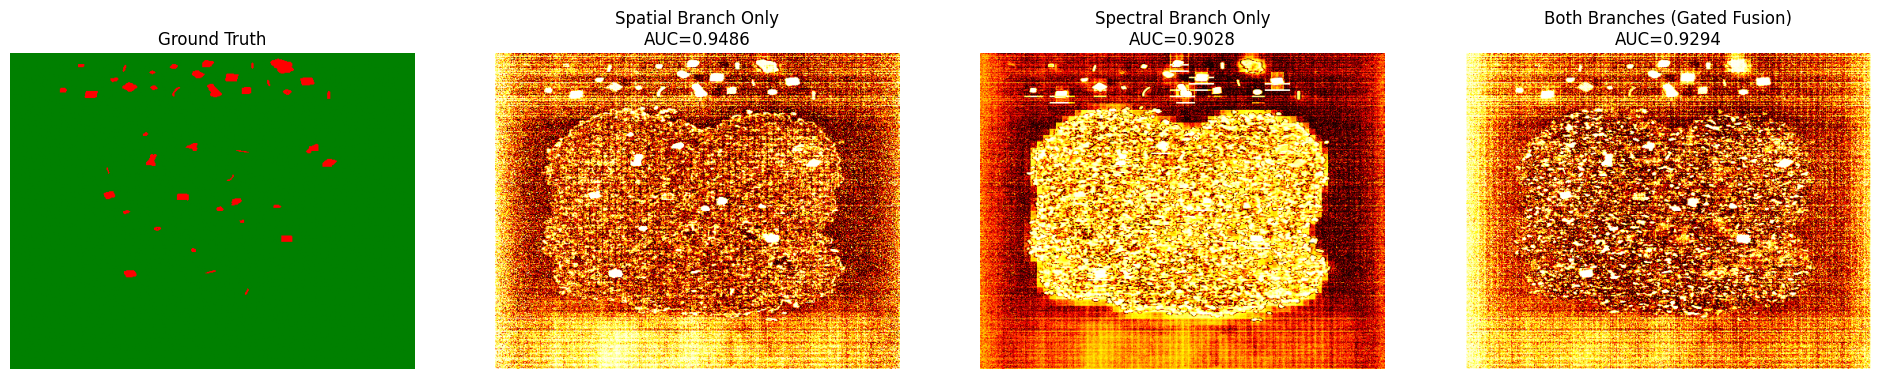

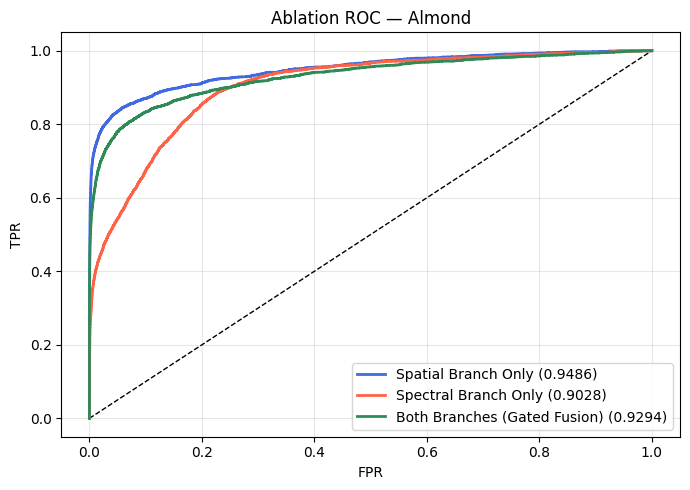


Ablation Summary:
  Mode                                 ROC-AUC
  ---------------------------------------------
  Spatial Branch Only                 0.9486
  Spectral Branch Only                0.9028
  Both Branches (Gated Fusion)        0.9294
Membuat Ablation Excel baru
Ablation Excel disimpan: /content/drive/MyDrive/Master/Research/HAD-Experiment/Result-2/results/DMS2F_HAD_AblationResults.xlsx


In [ ]:
ABLATION_MODES = [
    ('spatial',  'Spatial Branch Only'),
    ('spectral', 'Spectral Branch Only'),
    ('full',     'Both Branches (Gated Fusion)'),
]
abl_results = {}

for mode, mode_label in ABLATION_MODES:
    print(f"\n--- Mode: {mode_label} ---")
    m = AnomalyDetectionModel(
        in_channels=B, mode=mode, dim=DIM, depth=DEPTH,
        spec_num=SPEC_NUM, spec_rate=SPEC_RATE, spa_token=SPA_TOKEN
    ).to(device)


    abl_exp = f'{FOOD_TYPE}_dms2f_{mode}'
    m, _, _ = train_dms2f(
        m, train_loader, val_loader,
        test_blocks, test_positions,
        epochs=EPOCHS, lr=LR, wd=WEIGHT_DECAY,
        device=str(device), exp_name=abl_exp,
        drive_ckpt_dir=DRIVE_CKPT_DIR, ckpt_every=5
    )

    # Load BEST checkpoint untuk inference (bukan state terakhir)
    best_path = os.path.join(DRIVE_MODEL_DIR, f'{abl_exp}_best.pt')
    if os.path.exists(best_path):
      best_ckpt = torch.load(best_path, map_location=device, weights_only=False)
      m.load_state_dict(best_ckpt['state_dict'], strict=False)
      print(f"  Loaded BEST model: epoch {best_ckpt['epoch']}, "
            f"ROC-AUC={best_ckpt['auc']:.4f}")



    # Inference
    m.eval()
    recs_abl = []
    with torch.no_grad():
        for blk, _ in DataLoader(test_dataset, batch_size=BATCH_SIZE,
                                  num_workers=2, pin_memory=True):
            out, _ = m(blk.to(device))
            recs_abl.append(out.cpu())
    recs_abl  = torch.cat(recs_abl)
    recon_abl = block_fold(recs_abl, (H_test, W_test),
                            BLOCK_SIZE, STRIDE_PATCH, test_positions)
    orig_map  = torch.tensor(test_data.astype(np.float32)).permute(2,0,1)
    res_abl   = torch.norm(recon_abl - orig_map, dim=0).numpy()
    s1d_abl   = (rankdata(res_abl.ravel()) / res_abl.size).ravel()
    auc_abl   = roc_auc_score(label_1d, s1d_abl)
    f_abl, t_abl, _ = roc_curve(label_1d, s1d_abl)
    abl_results[mode_label] = (s1d_abl.reshape(H_test, W_test), auc_abl, f_abl, t_abl)
    print(f"  ROC-AUC: {auc_abl:.4f}")

# ─── Ablation figure ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(ABLATION_MODES)+1,
                          figsize=(6*(len(ABLATION_MODES)+1), 5))
axes[0].imshow(label_map, cmap=ListedColormap(['green','red']))
axes[0].set_title('Ground Truth'); axes[0].axis('off')

colors_abl = ['royalblue','tomato','seagreen']
fig_roc, ax_roc_abl = plt.subplots(figsize=(7,5))
ax_roc_abl.plot([0,1],[0,1],'k--',lw=1)

for i, (ml, (smap, av, f, t)) in enumerate(abl_results.items()):
    axes[i+1].imshow(smap, cmap='hot')
    axes[i+1].set_title(f'{ml}\nAUC={av:.4f}'); axes[i+1].axis('off')
    ax_roc_abl.plot(f, t, color=colors_abl[i], lw=2, label=f'{ml} ({av:.4f})')

ax_roc_abl.set_xlabel('FPR'); ax_roc_abl.set_ylabel('TPR')
ax_roc_abl.set_title(f'Ablation ROC — {FOOD_TYPE}')
ax_roc_abl.legend(loc='lower right'); ax_roc_abl.grid(True, alpha=0.3)
fig_roc.tight_layout()
fig_roc.savefig(f'artifacts/results/{FOOD_TYPE}_ablation_roc.png', dpi=150, bbox_inches='tight')
plt.show()
fig.tight_layout()
fig.savefig(f'artifacts/results/{FOOD_TYPE}_ablation_maps.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAblation Summary:")
print(f"  {'Mode':<35} {'ROC-AUC':>8}")
print("  " + "-"*45)
for ml, (_, av, _, _) in abl_results.items():
    print(f"  {ml:<35} {av:.4f}")

# ─── Save Ablation Results ke Excel ───────────────────────────────────────────
ABL_EXCEL_DRIVE = os.path.join(DRIVE_RESULT_DIR, 'DMS2F_HAD_AblationResults.xlsx')
ABL_EXCEL_LOCAL = 'artifacts/results/DMS2F_HAD_AblationResults.xlsx'

abl_headers = ['Timestamp', 'Food Type', 'Mode', 'ROC-AUC', 'PR-AUC', 'Epochs']

# Hitung PR-AUC juga untuk tiap mode
abl_metrics = {}
for ml, (smap, auc_v, f_val, t_val) in abl_results.items():
    s1d = smap.ravel()

    # Cara benar hitung PR-AUC
    prec_v, rec_v, _ = precision_recall_curve(label_1d, s1d)
    pr_auc_v = auc(rec_v, prec_v)
    abl_metrics[ml] = (auc_v, pr_auc_v)

if os.path.exists(ABL_EXCEL_DRIVE):
    shutil.copy2(ABL_EXCEL_DRIVE, ABL_EXCEL_LOCAL)
    wb_abl = openpyxl.load_workbook(ABL_EXCEL_LOCAL)
    ws_abl = wb_abl.active
    next_row = ws_abl.max_row + 1
    print(f"Append ke Ablation Excel (baris {next_row})")
else:
    wb_abl = openpyxl.Workbook()
    ws_abl = wb_abl.active
    ws_abl.title = 'Ablation'
    ws_abl.append(abl_headers)
    style_header(ws_abl, len(abl_headers))
    ws_abl.row_dimensions[1].height = 30
    next_row = 2
    print("Membuat Ablation Excel baru")

ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
for ml, (auc_v, pr_v) in abl_metrics.items():
    ws_abl.append([ts, FOOD_TYPE, ml, round(auc_v, 4), round(pr_v, 4), EPOCHS])
    style_row(ws_abl, next_row, len(abl_headers), alt=(next_row % 2 == 0))
    ws_abl.row_dimensions[next_row].height = 20
    next_row += 1

auto_width(ws_abl)
wb_abl.save(ABL_EXCEL_LOCAL)
shutil.copy2(ABL_EXCEL_LOCAL, ABL_EXCEL_DRIVE)
print(f"Ablation Excel disimpan: {ABL_EXCEL_DRIVE}")

# Sync ablation figures ke Drive
for fname in os.listdir('artifacts/results'):
    shutil.copy2(os.path.join('artifacts/results', fname),
                 os.path.join(DRIVE_RESULT_DIR, fname))
